## TRABAJO PRÁCTICO 2

### PARTE 1 - Métrica de Image Sharpness Measure for Blurred Images in Frequency Domain

En esta primera parte se busca implementar un algoritmo que calcule la métrica propuesta en Image Sharpness Measure for Blurred Images in Frequency Domain. Para ello, el paper, define la siguiente serie de pasos a realizar:


*Entrada:* Imagen I de tamaño M×N.

*Salida:* Image Quality measure (FM) donde FM significa Frequency Domain Image Blur Measure.
1. Calcular F que es la Transformada de Fourier de la imagen I.
2. Encontrar Fc que se obtiene al hacer el shift de F al origen.
3. Calcular AF = abs (Fc) donde AF es el valor absoluto de Fc.
4. Calcular M = max (AF) donde M es el máximo valor de frecuencia en F.
5. Calcular $T_H$ que es el total de pixeles en F cuyo valor > thres, donde thres = M/1000.
6. Calcular Image Quality measure (FM) a partir de la siguiente: 
$$ FM = \frac{T_H}{N\times M}$$

Luego se nos pide, calcular la métrica siguiendo los siguientes 3 experimentos, donde se mostrará una curva y los puntos máximos de enfoque:

1. Medición sobre todo el frame.
2. Medición sobre ROI centrada en el frame (del 5% o 10%).
3. Usar matriz de enfoque de NxM elementos rectangulares equiespaciados.

Para realizar lo pedido, se plantea el siguiente script que se compone de las siguientes funciones principales:

* `calculo_fm(img)`: Función que se encarga del cálculo de la métrica
* `calculo_roi(img, percent)`: Función que calcula el ROI según porcentaje
* `fm_matriz_enfoque(img, n, m)`: Función que calcula la métrica total de las matrices de enfoque NxM

Por otro lado, el algoritmo deberá detectar y devolver los puntos de máximo enfoque de manera automática, como podrán resultar varios, se implementa un umbral del 98% respecto del valor máximo encontrado para obtener aquellos donde resultará máximo.

Termino de procesar video
Resultados del algoritmo:
Frames enfocados según Frame completo: [ 90  91  93  95  97  99 101 103 105 107 109 110 111 113]
Frames enfocados según ROI 10%: [ 90  91  93  95  97  99 100 101 103 104 105 106 107 109 110 111 112 113]
Frames enfocados según 5x5: [68 70 72 73 74 75 76 77 78 80 82]
Frames enfocados según 7x5: [ 66  68  69  70  71  72  73  74  76  77  78  80  82 117 118 119 120]
Frames enfocados según 11x11: [ 60  62  63  64  65  66  67  68  69  70  71  72  73  74  76  77  78  80
  82  84  86  88 117 119 120]


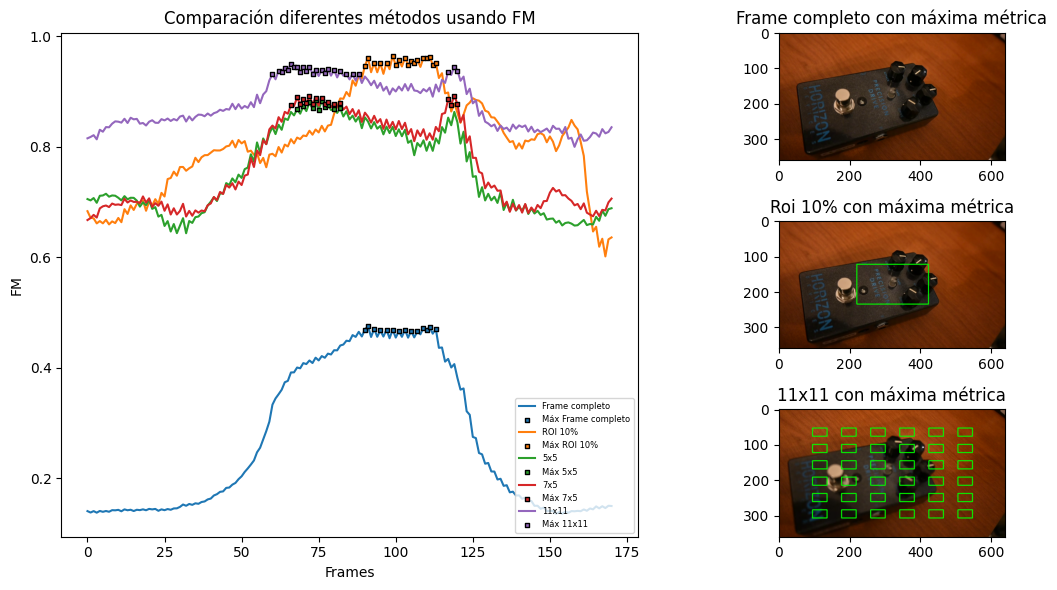

In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Calculo FM de la imagen ingresada (podrá ser frame completo o roi)
def calculo_fm(img):
    # Usos pasos del algoritmo en el paper Image Sharpness Meassure for Blurred Images in Frequency Domain
    height, width = img.shape[:2]
    fft = np.fft.fft(cv.cvtColor(img, cv.COLOR_RGB2GRAY))
    Fc = np.fft.fftshift(fft)
    Af = np.abs(Fc)
    M = np.max(Af)
    Th = np.count_nonzero(Af > M/1000)
    FM = Th/(width*height)
    return FM

# Calculo ROI con porcentaje variable
def calculo_roi(img, percent):

    height, width = img.shape[:2]
    center_x = width//2
    center_y = height//2
    roi_width = int(width*np.sqrt(percent/100)) # Con el porcentaje obtengo el ancho
    roi_height = int(height*np.sqrt(percent/100)) # Con el porcentaje obtengo la altura
    y_bottom = center_y + roi_height//2
    y_top = center_y - roi_height//2
    x_right = center_x + roi_width//2
    x_left = center_x - roi_width//2

    roi = img[y_top:y_bottom, x_left:x_right] # Tomo la ROI de la imagen
    return roi, y_top, y_bottom, x_left, x_right

# Calculo cantidad de matrices de enfoque y posiciones, para luego ver promedio de la métrica, considero un ROI del 50%
def fm_matriz_enfoque(img, n, m):
    # Chequear n y m son impares
    if n % 2 != 0 and m % 2 != 0:
        roi, y_top, y_bottom, x_left, x_right = calculo_roi(img, 50)
        height, width = roi.shape[:2]
        grid_x = width//m
        grid_y = height//n

        total_matrices = 0
        total_matriz_enfoque = 0
        # Hago loop por la grilla y calculo la métrica para cada elemento
        for i in range(0,n,2):
            for j in range(0,m,2):
                y_start = i*grid_y
                y_end = (i+1)*grid_y
                x_start =j*grid_x
                x_end = (j+1)*grid_x
                matriz = roi[y_start:y_end,x_start:x_end]
                total_matriz_enfoque += calculo_fm(matriz)
                total_matrices += 1
                cv.rectangle(img, (x_start+x_left,y_start+y_top), (x_end+x_left,y_end+y_top), (0,255,0),2) # Hago bounding box en cada elemento de la grilla

        return total_matriz_enfoque/total_matrices # Promedio de los resultados de la métrica
    else:
        print("Verificar que N y M sean impares")
        return

# Inicio Video Capture
cap = cv.VideoCapture('focus_video.mov')

# Inicializo resultados
FMs_frame_completo = []
FMs_roi_centro = []
FMs_matriz_enfoque = [[],[],[]]

# Imagenes con futuras bounding boxes
base_images = []
roi_images = []
focus_images = []

# Hagoo loop por Video Capture
while cap.isOpened():
    # Leo un frame
    ret, frame = cap.read()
    # Reviso que exista
    if ret:
        img = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
        base_images.append(img)
        # Hago copias para marcar en la imagen los diferentes métodos utilizados
        img_1 = img.copy()
        img_2 = img.copy()
        img_3 = img.copy()
        img_4 = img.copy()

        # Calculo con Frame Completo
        FMs_frame_completo.append(calculo_fm(img))

        # Calculo con ROI
        roi, y_top, y_bottom, x_left, x_right = calculo_roi(img_1, 10)
        FMs_roi_centro.append(calculo_fm(roi)) # el porcentaje va de 0 a 100
        cv.rectangle(img_1, (x_left, y_top), (x_right, y_bottom), (0,255,0), 2)
        roi_images.append(img_1)

        # Calculo con matriz de enfoque, se elige matriz según NxM buscado, deben ser impares
        FMs_matriz_enfoque[0].append(fm_matriz_enfoque(img_2, 5, 5)) # 5x5
        FMs_matriz_enfoque[1].append(fm_matriz_enfoque(img_3, 7, 5)) # 7x5
        FMs_matriz_enfoque[2].append(fm_matriz_enfoque(img_4, 11, 11)) # 11x11
        focus_images.append(img_4)

    else:
        print("Termino de procesar video")
        break

cap.release()
cv.destroyAllWindows()

frames = np.arange(0, len(base_images))

# Organizo los elementos en una lista para ver los máximos
metodos = [np.array(FMs_frame_completo), np.array(FMs_roi_centro), np.array(FMs_matriz_enfoque[0]), np.array(FMs_matriz_enfoque[1]), np.array(FMs_matriz_enfoque[2])]
nombres = ["Frame completo", "ROI 10%", "5x5", "7x5", "11x11"]
frames_max = []
max_fm = []
tolerancia = 0.98

# Calculo de los máximos con umbral
print("Resultados del algoritmo:")
for j in range(len(metodos)):
    umbral_j = np.max(metodos[j])*tolerancia
    mascara_j = metodos[j] >= umbral_j
    frames_max.append(frames[mascara_j])
    max_fm.append(metodos[j][mascara_j])
    print(f"Frames enfocados según {nombres[j]}:", frames_max[j])


# Gráfico comparando las distintas métricas FM
layout = """
AB
AC
AD
"""
fig, ax = plt.subplot_mosaic(layout, figsize=(12,6))
for i in range(len(metodos)):
    # Ploteo métricas según método
    ax["A"].plot(frames, metodos[i], label=nombres[i], c=f"C{i}", zorder=1)
    # Ploteo máximos por algoritmo
    ax["A"].scatter(frames_max[i], max_fm[i], s=10, c=f"C{i}", marker="s", edgecolors='black', label=f"Máx {nombres[i]}", zorder=2)
ax["A"].set_title("Comparación diferentes métodos usando FM")
ax["A"].set_xlabel("Frames")
ax["A"].set_ylabel("FM")
ax["A"].legend(loc="lower right", fontsize=6)

# Muestro resultados
ax["B"].imshow(base_images[FMs_frame_completo.index(max(FMs_frame_completo))])
ax["B"].set_title("Frame completo con máxima métrica")
ax["C"].imshow(roi_images[FMs_roi_centro.index(max(FMs_roi_centro))])
ax["C"].set_title("Roi 10% con máxima métrica")
ax["D"].imshow(focus_images[FMs_matriz_enfoque[2].index(max(FMs_matriz_enfoque[2]))])
ax["D"].set_title("11x11 con máxima métrica")

plt.tight_layout()
#plt.savefig("test.png", dpi=400)
plt.show()



A partir de los resultados obtenidos, podemos observar como tomar un ROI del 10% produjo un aumento del valor de la métrica FM y devuelve aproximadamente los mismos frames de máximo enfoque que tomar todo el frame completo. Por otro lado, usar una matriz de enfoque genera un valle sobre la curva, lo que se traduce en 2 nuevos máximos locales que compiten, pero que valen relativamente lo mismo. En el caso de una matriz de 11x11, se obtienen máximos inmediatamente antes y después que los obtenidos anteriormente. Si se observan estos en el video, se podrá ver que no resultan ser los más enfocados a simplemente vista, por lo que no resulta tan acertada.

A pesar de lo obtenido anteriormente, lo probe con otro video dentro de la carpeta tests. A lo largo de este, se puede ver un corto enfoque alrededor del segundo 1 y un periodo de mayor enfoque sobre el segundo 7 al final del video. Al utilizar el script anterior se obtiene el siguiente resultado mostrado. Si observamos la métrica sobre el experimento según el frame completo, se ve claramente el 1° pico de enfoque y luego el enfoque más prolongado.

![Test enfoque](tests/test_1.png "Test enfoque")

### PARTE 2 - Métrica de Analysis of focus measure operators in shapefrom-focus

Para esta parte del trabajo, se implentará alguno de los algoritmos encontrados en el Apéndice del paper Analysis of focus measure operators in shapefrom-focus. Se elige el siguiente:

**Brenner's focus measure (MIS2)** 

Este es una medida del enfoque basada en la segunda diferencia del nivel de gris de la imagen y se define como:
$$\phi=\sum_{(i,j)}\left|I(i,j)-I(i+2,j)\right|^2$$

Esta medida del enfoque se adapta para nuestro caso y se normaliza por la cantidad de pixeles que afectan a su medición, según se trate del frame completo, ROI o matriz de enfoque.

Al igual que en la primera parte, se plantea el siguiente script que se compone de las siguientes funciones principales:

* `calculo_MIS2(img)`: Función que se encarga del cálculo de la métrica
* `calculo_roi(img, percent)`: Función que calcula el ROI según porcentaje
* `MIS2_matriz_enfoque(img, n, m)`: Función que calcula la métrica total de las matrices de enfoque NxM

Por otro lado, el algoritmo deberá detectar y devolver los puntos de máximo enfoque de manera automática, como podrán resultar varios, se implementa un umbral del 98% respecto del valor máximo encontrado para obtener aquellos donde resultará máximo.

Termino de procesar video
Resultados del algoritmo:
Frames enfocados según Frame completo: [109 111]
Frames enfocados según ROI 10%: [109 111 112 113]
Frames enfocados según 5x5: [97 98 99]
Frames enfocados según 7x5: [109 110 111]
Frames enfocados según 11x11: [96 97 98 99]


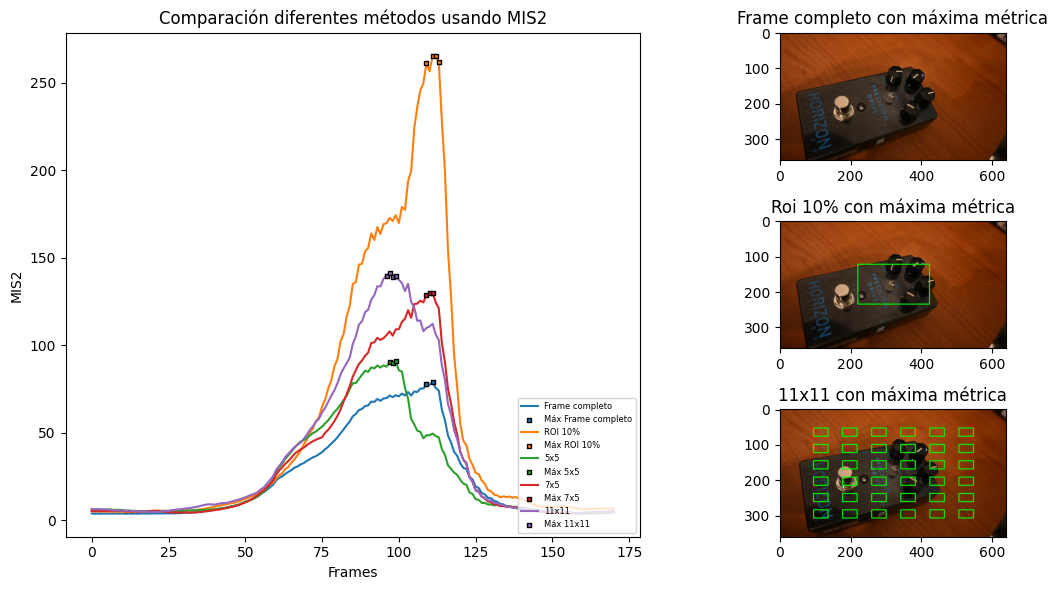

In [8]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Calculo MIS2 de la imagen ingresada (podrá ser frame completo o roi)
def calculo_MIS2(img):
    img = cv.cvtColor(img, cv.COLOR_RGB2GRAY) # Convierto a gray
    height, width = img.shape[:2]
    img = img.astype(np.float64)
    I_base = img[:,:-2]
    I_desplazada = img[:,2:]
    diff = I_base - I_desplazada
    diff_sq = np.sum(diff**2)
    return diff_sq/(diff.shape[0]*diff.shape[1])

# Calculo ROI con porcentaje variable
def calculo_roi(img, percent):

    height, width = img.shape[:2]
    center_x = width//2
    center_y = height//2
    roi_width = int(width*np.sqrt(percent/100)) # Con el porcentaje obtengo el ancho
    roi_height = int(height*np.sqrt(percent/100)) # Con el porcentaje obtengo la altura
    y_bottom = center_y + roi_height//2
    y_top = center_y - roi_height//2
    x_right = center_x + roi_width//2
    x_left = center_x - roi_width//2

    roi = img[y_top:y_bottom, x_left:x_right] # Tomo la ROI de la imagen
    return roi, y_top, y_bottom, x_left, x_right

# Calculo cantidad de matrices de enfoque y posiciones, para luego ver promedio de la métrica, considero un ROI del 50%
def MIS2_matriz_enfoque(img, n, m):
    # Chequear n y m son impares
    if n % 2 != 0 and m % 2 != 0:
        roi, y_top, y_bottom, x_left, x_right = calculo_roi(img, 50)
        height, width = roi.shape[:2]
        grid_x = width//m
        grid_y = height//n

        total_matrices = 0
        total_matriz_enfoque = 0
        # Hago loop por la grilla y calculo la métrica para cada elemento
        for i in range(0,n,2):
            for j in range(0,m,2):
                y_start = i*grid_y
                y_end = (i+1)*grid_y
                x_start =j*grid_x
                x_end = (j+1)*grid_x
                matriz = roi[y_start:y_end,x_start:x_end]
                total_matriz_enfoque += calculo_MIS2(matriz)
                total_matrices += 1
                cv.rectangle(img, (x_start+x_left,y_start+y_top), (x_end+x_left,y_end+y_top), (0,255,0),2) # Hago bounding box en cada elemento de la grilla

        return total_matriz_enfoque/total_matrices # Promedio de los resultados de la métrica
    else:
        print("Verificar que N y M sean impares")
        return

# Inicio Video Capture
cap = cv.VideoCapture('focus_video.mov')

# Inicializo resultados
MIS2_frame_completo = []
MIS2_roi_centro = []
MIS2_matrices_enfoque = [[],[],[]]

# Imagenes con futuras bounding boxes
base_images = []
roi_images = []
focus_images = []

# Hagoo loop por Video Capture
while cap.isOpened():
    # Leo un frame
    ret, frame = cap.read()
    # Reviso que exista
    if ret:
        img = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
        base_images.append(img)
        # Hago copias para marcar en la imagen los diferentes métodos utilizados
        img_1 = img.copy()
        img_2 = img.copy()
        img_3 = img.copy()
        img_4 = img.copy()

        # Calculo con Frame Completo
        MIS2_frame_completo.append(calculo_MIS2(img))

        # Calculo con ROI
        roi, y_top, y_bottom, x_left, x_right = calculo_roi(img_1, 10)
        MIS2_roi_centro.append(calculo_MIS2(roi)) # el porcentaje va de 0 a 100
        cv.rectangle(img_1, (x_left, y_top), (x_right, y_bottom), (0,255,0), 2)
        roi_images.append(img_1)

        # Calculo con matriz de enfoque, se elige matriz según NxM buscado, deben ser impares
        MIS2_matrices_enfoque[0].append(MIS2_matriz_enfoque(img_2, 5, 5)) # 5x5
        MIS2_matrices_enfoque[1].append(MIS2_matriz_enfoque(img_3, 7, 5)) # 7x5
        MIS2_matrices_enfoque[2].append(MIS2_matriz_enfoque(img_4, 11, 11)) # 11x11
        focus_images.append(img_4)

    else:
        print("Termino de procesar video")
        break

cap.release()
cv.destroyAllWindows()

frames = np.arange(0, len(base_images))

# Organizo los elementos en una lista para ver los máximos
metodos = [np.array(MIS2_frame_completo), np.array(MIS2_roi_centro), 
           np.array(MIS2_matrices_enfoque[0]), np.array(MIS2_matrices_enfoque[1]), np.array(MIS2_matrices_enfoque[2])]
nombres = ["Frame completo", "ROI 10%", "5x5", "7x5", "11x11"]
frames_max = []
max_fm = []
tolerancia = 0.98

# Calculo de los máximos con umbral
print("Resultados del algoritmo:")
for j in range(len(metodos)):
    umbral_j = np.max(metodos[j])*tolerancia
    mascara_j = metodos[j] >= umbral_j
    frames_max.append(frames[mascara_j])
    max_fm.append(metodos[j][mascara_j])
    print(f"Frames enfocados según {nombres[j]}:", frames_max[j])


# Gráfico comparando las distintas métricas FM
layout = """
AB
AC
AD
"""
fig, ax = plt.subplot_mosaic(layout, figsize=(12,6))
# Ploteo resultados totales
for i in range(len(metodos)):
    # Ploteo métricas según método
    ax["A"].plot(frames, metodos[i], label=nombres[i], c=f"C{i}", zorder=1)
    # Ploteo máximos por algoritmo
    ax["A"].scatter(frames_max[i], max_fm[i], s=10, c=f"C{i}", marker="s", edgecolors='black', label=f"Máx {nombres[i]}", zorder=2)
ax["A"].set_title("Comparación diferentes métodos usando MIS2")
ax["A"].set_xlabel("Frames")
ax["A"].set_ylabel("MIS2")
ax["A"].legend(loc="lower right", fontsize=6)

# Muestro resultados
ax["B"].imshow(base_images[MIS2_frame_completo.index(max( MIS2_frame_completo))])
ax["B"].set_title("Frame completo con máxima métrica")
ax["C"].imshow(roi_images[MIS2_roi_centro.index(max(MIS2_roi_centro))])
ax["C"].set_title("Roi 10% con máxima métrica")
ax["D"].imshow(focus_images[MIS2_matrices_enfoque[2].index(max(MIS2_matrices_enfoque[2]))])
ax["D"].set_title("11x11 con máxima métrica")

plt.tight_layout()
#plt.savefig("test.png",dpi=400)
plt.show()

A partir de los resultados obtenidos, podemos observar como los resultados del máximo enfoque tiene un resultado más claro, sin tanto ruido y con una zona de máximos bien definida para todos los casos. Podemos ver que tanto el frame completo, el ROI 10% y el 7x5 devuelven máximos en la misma zona, a diferencia del 5x5 y 11x11 que devuelven una zona de máximo antes que no resulta tan adecuada.

Si lo comparamos con la métrica de la primera parte, esta resulta mejor ya que define con mayor claridad la zona de enfoque máximo. Esto se puede ver claramente al analizar el otro video que se analizo con la primera métrica, donde con esta segunda métrica obtenemos el siguiente resultado.

![Test enfoque](tests/test_2.png "Test enfoque")

Aquí se ve claramente, que sin importar el tipo de experimento, todos detectan los picos de mayor enfoque con gran precisión. Por lo que se puede concluir, a partir de los resultados obtenidos, que la segunda métrica elegida tiene una mayor capacidad para detectar los frames de máximo enfoque.